# 实战Kaggle比赛:预测房价

In [48]:
import hashlib
import os
import tarfile
import zipfile
import requests
#@save

DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

download函数用来下载数据集

In [49]:
def download(name, cache_dir=os.path.join('..', 'data')):  # @save
    """下载一个DATA_HUB中的文件, 返回本地文件名"""

    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]

    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])

    # 如果文件已存在，校验 SHA1
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)  # 每次读取1MB
                if not data:
                    break
                sha1.update(data)

        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存

    # 下载文件
    print(f'正在从 {url} 下载 {fname}...')
    r = requests.get(url, stream=True, verify=True)

    with open(fname, 'wb') as f:
        f.write(r.content)

    return fname

实现两个实用函数:一个将下载并解压缩一个zip或tar文件,另一个是将本书中使用的所有数据集从DATA_HUB下载到缓存目录中

In [50]:
def download_extract(name, folder=None):  # @save
    """下载并解压 zip/tar 文件"""

    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)

    # 选择解压方式
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        raise ValueError('只有 zip/tar 文件可以被解压缩')

    # 解压
    fp.extractall(base_dir)
    fp.close()

    return os.path.join(base_dir, folder) if folder else data_dir


def download_all():  # @save
    """下载 DATA_HUB 中的所有文件"""
    for name in DATA_HUB:
        download(name)

In [51]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l


# 训练集
DATA_HUB['kaggle_house_train'] = (  # @save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce'
)

# 测试集
DATA_HUB['kaggle_house_test'] = (  # @save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90'
)

train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

# 加载原始数据（必须先运行）
train_data = pd.read_csv('../data/kaggle_house_pred_train.csv')
test_data = pd.read_csv('../data/kaggle_house_pred_test.csv')

## 数据预处理

In [52]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
# 若无法获得测试数据,则可根据训练数据计算均值和标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
# 在标准化数据之后,所有均值消失,因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

我们用独热编码替换它们,方法与前面将多类别标签转换为向量的方式相同(请参见 3.4.1节)。
例如,“MSZoning”包含值“RL”和“Rm”。我们将创建两个新的指示器特征“MSZoning_RL”和“MSZoning_RM”,其值为0或1。
根据独热编码,如果“MSZoning”的原始值为“RL”,则:“MSZoning_RL”为1,“MSZoning_RM”为0。
pandas软件包会自动为我们实现这一点

In [53]:
# “Dummy_na=True”将“na”(缺失值)视为有效的特征值,并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features = all_features.astype('float32')
all_features.shape

(2919, 330)

In [54]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

## 训练

In [55]:
loss = nn.MSELoss()
in_features = train_features.shape[1]
def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net


房价就像股票价格一样,我们关心的是相对数量,而不是绝对数量

例如,如果我们在俄亥俄州农村地区估计一栋房子的价格时,假设我们的预测偏差了10万美元,然而那里一栋典型的房子的价值是12.5万美元,那么模型可能做得很糟糕。
另一方面,如果我们在加州豪宅区的预测出现同样的10万美元的偏差,(在那里,房价中位数超过400万美元)这可能是一个不错的预测

解决这个问题的一种方法是用价格预测的对数来衡量差异。事实上,这也是比赛中官方用来评价提交质量的误差指标

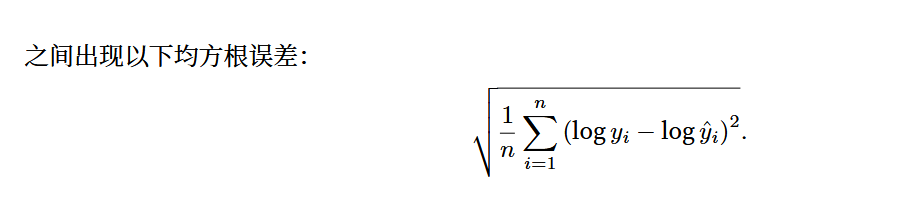

In [56]:
def log_rmse(net, features, labels):
# 为了在取对数时进一步稳定该值,将小于1的值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),  torch.log(labels)))
    return rmse.item()

In [57]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):

    train_ls, test_ls = [], []

    # 数据迭代器
    train_iter = d2l.load_array((train_features, train_labels), batch_size)

    # 使用Adam优化器
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        # 记录训练误差
        train_ls.append(log_rmse(net, train_features, train_labels))

        # 记录测试误差
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))

    return train_ls, test_ls

# k折交叉验证

K折交叉验证,它有助于模型选择和超参数调整。我们首先需  要定义一个函数,在K折交叉验证过程中返回第i折的数据。
具体地说,它选择第i个切片作为验证数据,其余部分作为训练数据。注意,这并不是处理数据的最有效方法,如果我们的数据集大得多,会有其他解决办法

In [58]:
def get_k_fold_data(k, i, X, y):
    assert k > 1

    fold_size = X.shape[0] // k
    X_train, y_train = None, None

    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]

        if j == i:
            # 验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            # 第一次赋值训练集
            X_train, y_train = X_part, y_part
        else:
            # 拼接训练集
            X_train = torch.cat([X_train, X_part], dim=0)
            y_train = torch.cat([y_train, y_part], dim=0)

    return X_train, y_train, X_valid, y_valid

当我们在K折交叉验证中训练K次后,返回训练和验证误差的平均值。

In [59]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0

    for i in range(k):
        # 获取第 i 折数据
        data = get_k_fold_data(k, i, X_train, y_train)

        # 初始化模型
        net = get_net()

        # 训练
        train_ls, valid_ls = train(
            net, *data,
            num_epochs, learning_rate, weight_decay, batch_size
        )

        # 累加最后一轮的loss
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]

        # 画图（只画一次）
        if i == 0:
            d2l.plot(
                list(range(1, num_epochs + 1)),
                [train_ls, valid_ls],
                xlabel='epoch',
                ylabel='rmse',
                xlim=[1, num_epochs],
                legend=['train', 'valid'],
                yscale='log'
            )

        # 打印每一折结果
        print(f'折{i + 1}, 训练log rmse {float(train_ls[-1]):f}, '
              f'验证log rmse {float(valid_ls[-1]):f}')

    # 返回平均loss
    return train_l_sum / k, valid_l_sum / k

# 模型选择

折1, 训练log rmse 0.330463, 验证log rmse 0.332860
折2, 训练log rmse 0.327703, 验证log rmse 0.344088
折3, 训练log rmse 0.327559, 验证log rmse 0.340529
折4, 训练log rmse 0.332518, 验证log rmse 0.309710
折5, 训练log rmse 0.328170, 验证log rmse 0.336489
5-折验证: 平均训练log rmse: 0.329283, 平均验证log rmse: 0.332735


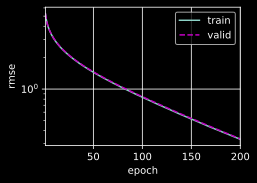

In [60]:
k, num_epochs, lr, weight_decay, batch_size = 5, 200, 2, 0, 128
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,  weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '  f'平均验证log rmse: {float(valid_l):f}')

# 提交Kaggle预测

In [61]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):

    # 初始化模型
    net = get_net()

    # 训练（这里没有验证集，所以传 None）
    train_ls, _ = train(
        net,
        train_features, train_labels,
        None, None,
        num_epochs, lr, weight_decay, batch_size
    )

    # 画训练曲线
    d2l.plot(
        np.arange(1, num_epochs + 1),
        [train_ls],
        xlabel='epoch',
        ylabel='log rmse',
        xlim=[1, num_epochs],
        yscale='log'
    )

    print(f'训练log rmse: {float(train_ls[-1]):f}')

    # ======================
    # 预测测试集
    # ======================
    preds = net(test_features).detach().numpy()

    # 格式调整（Kaggle要求一列）
    test_data['SalePrice'] = pd.Series(preds.reshape(-1))

    # 拼接提交文件
    submission = pd.concat(
        [test_data['Id'], test_data['SalePrice']],
        axis=1
    )

    # 保存
    submission.to_csv('submission.csv', index=False)

真实数据通常混合了不同的数据类型,需要进行预处理。

常用的预处理方法:将实值数据重新缩放为零均值和单位方法;用均值替换缺失值。

将类别特征转化为指标特征,可以使我们把这个特征当作一个独热向量来对待。

我们可以使用K折交叉验证来选择模型并调整超参数。

对数对于相对误差很有用。